In [1]:
import functions
import os
from data import data, path_map, masks, path_masks, color_corrections
import healpy as hp
import numpy as np
from astropy.io import fits

In [2]:
# Reload functions module to get latest changes
import importlib
importlib.reload(functions)

<module 'functions' from '/home/pablo/Desktop/master/tfm/python/1-methodology_tests/functions.py'>

In [ ]:
# Default configuration
nside = 512
n_sim = 100
path_save = path_map + 'PYSM/'

quijote_bands = ['11']
wmap_bands = ['23', '33', '41', '61', '94']
planck_bands = ['30', '44', '70', '100', '143', '217', '353']


band_list = quijote_bands + wmap_bands + planck_bands

name_suffix = '_full_bin_20-199'

# Differential Assemblies (DAs) per frequency band
BANDS = {
    'K': ['K1'],
    'Ka': ['Ka1'],
    'Q': ['Q1', 'Q2'],
    'V': ['V1', 'V2'],
    'W': ['W1', 'W2', 'W3', 'W4'],
}

lmax = 2 * nside - 1
dl = 10

mask_select = masks['QUIJOTE_galcut']['galcut10']
mask_name = mask_select['name']
use_simulated_maps = False
use_white_noise = False
use_noise = False # Use noise simulations instead of the HMDM
out_path = '/home/pablo/Desktop/master/tfm/spectra/'
path_spectra = os.path.join(out_path, f'power_spectra_{mask_name}{name_suffix}.fits')
if use_noise:
    path_hmdm_spectra = os.path.join(out_path, f'power_spectra_{mask_name}_noise_sim{name_suffix}.fits')
else:
    path_hmdm_spectra = os.path.join(out_path, f'power_spectra_{mask_name}_hmdm{name_suffix}.fits')
path_avg_std_skyplusnoise = os.path.join(out_path, f'spectra_avg_std_{mask_name}_avg_std{n_sim}_skyplusnoise{name_suffix}.fits')
path_avg_std_noise = os.path.join(out_path, f'spectra_avg_std_{mask_name}_avg_std{n_sim}_noise{name_suffix}.fits')
path_full_skyplusnoise = os.path.join(out_path, f'spectra_full_{mask_name}_{n_sim}_skyplusnoise{name_suffix}.fits')
path_full_noise = os.path.join(out_path, f'spectra_full_{mask_name}_{n_sim}_noise{name_suffix}.fits')
path_corrected_spectra = os.path.join(out_path, f'corrected_power_spectra_{mask_name}{name_suffix}.fits')

mask = hp.read_map(mask_select['path'])

#Create binning scheme
ell_1 = [20, 40, 60, 80, 100, 120, 140, 160, 180]
ell_2 = [39, 59, 79, 99, 119, 139, 159, 179, 199]

binning_params = {
    'type': 'edges',  #'linear' or 'edges'
    'lmax': lmax,
    'dl': dl,
    # For edges
    'ell1': ell_1,
    'ell2': ell_2
}

$\textbf{Part 1: Simulated maps using PySM}$

In [ ]:

# Generate maps
functions.generate_sky_maps(nside, path_save, experiment_select='QUIJOTE', band_select=quijote_bands)
functions.generate_sky_maps(nside, path_save, experiment_select='WMAP', band_select=wmap_bands)
functions.generate_sky_maps(nside, path_save, experiment_select='Planck', band_select=planck_bands)

$\textbf{Part 2: Simulated white noise maps}$

In [ ]:
functions.white_noise_maps(data, nside, experiment_select='QUIJOTE', band_select=quijote_bands, n_sim=n_sim, path_map=path_map)
functions.white_noise_maps(data, nside, experiment_select='WMAP', band_select=wmap_bands, n_sim=n_sim, path_map=path_map)
functions.white_noise_maps(data, nside, experiment_select='Planck', band_select=planck_bands, n_sim=n_sim, path_map=path_map)

$\textbf{Part 3: Build HMDM}$

In [ ]:
base_dir = os.path.dirname(data['WMAP']['23']['hmdm'])
save_path = os.path.dirname(data['WMAP']['23']['hmdm'])

combined_1to4 = functions.coadd_year_range(base_dir=base_dir, year_1=1, year_2=4, save=True, save_path=save_path)
combined_5to9 = functions.coadd_year_range(base_dir=base_dir, year_1=5, year_2=9, save=True, save_path=save_path)

In [ ]:
functions.make_hmdm(data, band_list, save=True)

$\textbf{Part 4: Build beams WMAP}$

In [5]:
beam_path = os.path.dirname(data['WMAP']['23']['beam'])
save_path = os.path.dirname(data['WMAP']['23']['beam'])

functions.generate_band_beams(
    BANDS,
    beam_path=beam_path,
    save_path=save_path,
    data_dict=data,
    use_qu=True,     # use noise_QU for polarization beams
    mask_path=None
)

Saved band beam file: /media/pablo/cmb_ssd/maps/WMAP/beam/wmap_ampl_bl_K_9yr_v5p1.txt
Saved band beam file: /media/pablo/cmb_ssd/maps/WMAP/beam/wmap_ampl_bl_Ka_9yr_v5p1.txt
Saved band beam file: /media/pablo/cmb_ssd/maps/WMAP/beam/wmap_ampl_bl_Q_9yr_v5p1.txt
Saved band beam file: /media/pablo/cmb_ssd/maps/WMAP/beam/wmap_ampl_bl_V_9yr_v5p1.txt
Saved band beam file: /media/pablo/cmb_ssd/maps/WMAP/beam/wmap_ampl_bl_W_9yr_v5p1.txt


$\textbf{Part 5: Compute power spactra}$

In [ ]:
# 1. Prepare binning scheme
b = functions.create_binning(binning_params)

# 2. Precompute workspaces
workspaces = functions.prepare_workspaces(mask, b, nside, lmax=lmax, purify_e=True, purify_b=True)

In [5]:
# 3. Compute all spectra
spectra_matrix = functions.compute_all_power_spectra(
    data, band_list, mask, b,
    use_simulated_maps=use_simulated_maps,
    use_white_noise=use_white_noise,
    noise_realization=1,
    only_noise=False,
    workspaces=workspaces,
    lmax=lmax
)

# 4. Save spectra matrix into a FITS file
functions.save_spectra_to_fits(spectra_matrix, band_list, out_file=path_spectra)

Saved power spectra matrix to /home/pablo/Desktop/master/tfm/spectra/power_spectra_quijote_galcut10_full_bin_20-199.fits


In [6]:
# 5. Compute HMDM spectra
hmdm_spectra_matrix = functions.compute_hmdm_power_spectra(
    data, band_list, mask, b, workspaces=workspaces, lmax=lmax, use_noise=use_noise
)

# 6. Save spectra matrix into a FITS file
functions.save_spectra_to_fits(hmdm_spectra_matrix, band_list, out_file=path_hmdm_spectra)

Saved power spectra matrix to /home/pablo/Desktop/master/tfm/spectra/power_spectra_quijote_galcut10_hmdm_full_bin_20-199.fits


In [7]:
# 7. Read spectra matrix from FITS
spectra_dict = functions.read_spectra_from_fits(path_spectra, band_list)

In [ ]:
# 8. Compute mean and std over noise realizations (sky + noise)
avg_std_skyplusnoise_dict = functions.average_and_std_spectra(
    data, spectra_dict, band_list, mask, b,
    use_white_noise=use_white_noise,
    n_sim=n_sim, 
    only_noise=False,
    workspaces=workspaces,
    lmax=lmax
)


functions.save_avg_std_to_fits(avg_std_skyplusnoise_dict, band_list,
                     out_file=path_avg_std_skyplusnoise,
                     use_white_noise=use_white_noise
)


# 9. Compute mean and std for noise-only maps
avg_std_noise_dict = functions.average_and_std_spectra(
    data, spectra_dict, band_list, mask, b,
    use_white_noise=use_white_noise,
    n_sim=n_sim,
    only_noise=True,
    workspaces=workspaces,
    lmax=lmax
)

functions.save_avg_std_to_fits(avg_std_noise_dict, band_list,
                     out_file=path_avg_std_noise,
                     use_white_noise=use_white_noise
)

Simulations: 100%|██████████| 100/100 [51:34:13<00:00, 1856.53s/it]  


Saved avg+std spectra to /home/pablo/Desktop/master/tfm/spectra/spectra_avg_std_quijote_galcut10_avg_std100_skyplusnoise_full_bin_20-199.fits


Simulations: 100%|██████████| 100/100 [51:13:52<00:00, 1844.33s/it]  


Saved avg+std spectra to /home/pablo/Desktop/master/tfm/spectra/spectra_avg_std_quijote_galcut10_avg_std100_noise_full_bin_20-199.fits


In [ ]:
functions.save_sims_to_fits(avg_std_skyplusnoise_dict, band_list, 
                            out_file=path_full_skyplusnoise, 
                            use_white_noise=use_white_noise, 
                            sims_npz=None)



functions.save_sims_to_fits(avg_std_noise_dict, band_list, 
                            out_file=path_full_noise, 
                            use_white_noise=use_white_noise, 
                            sims_npz=None)
   

$\textbf{Part 6: Correct power spectra}$

In [11]:
# Path to Planck CMB spectrum (best-fit cosmology)
cmb_spectrum_file = '/home/pablo/Desktop/master/tfm/spectra/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt'

corr_spectra, out_file = functions.correct_power_spectra(
    path_spectra, path_avg_std_skyplusnoise, path_avg_std_noise,
    band_list, data, nside, 
    correct_beam=True, 
    correct_unit=True,                    # Convert to K²_RJ (Planck 2018 convention)
    correct_pixel=True, 
    save=True, 
    path_out_file=path_corrected_spectra,
    use_white_noise=use_white_noise, 
    path_hmdm_spectra=path_hmdm_spectra,
    subtract_cmb=True,                    # Subtract Planck CMB spectrum
    cmb_spectrum_path=cmb_spectrum_file   # Path to real Planck spectrum
)

[INFO] Loading CMB spectrum from /home/pablo/Desktop/master/tfm/spectra/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt
[INFO] Loaded CMB spectrum with format: Planck PLA
[OK] Saved corrected spectra with errors to /home/pablo/Desktop/master/tfm/spectra/corrected_power_spectra_quijote_galcut10_full_bin_20-199.fits
[OK] Saved corrected spectra with errors to /home/pablo/Desktop/master/tfm/spectra/corrected_power_spectra_quijote_galcut10_full_bin_20-199.fits


$\textbf{Part 8: MCMC fitting}$

In [3]:
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

'1'

In [11]:
# -------------------------------
# Fitting configuration (power-law with Gaussian priors and cross-only pairs)
# -------------------------------
from functions import set_gaussian_priors

# Gaussian priors:
# - beta_s ~ N(-3.1, 0.18)  synchrotron spectral index (frequency)
# - beta_d ~ N(1.55, 0.05)  dust spectral index (frequency)
# - alpha_s ~ N(-3.0, 0.30) synchrotron ell-slope (same for EE/BB)
# - alpha_d ~ N(-2.48, 0.20) dust ell-slope (average of Planck ~-2.42 EE and ~-2.54 BB)
#   Dust temperature T_d is fixed internally at 19.6 K (effectively a delta prior).

# set_gaussian_priors({
#     'beta_s': (-3.1, 0.18),
#     'beta_d': (1.55, 0.05),
#     'alpha_s': (-3.0, 0.30),
#     'alpha_d': (-2.48, 0.20),
# })

set_gaussian_priors(None)

fitting_mode = 'power-law'

# Multipole range
ell_min = 30
ell_max = 200

# Sampler configuration
nwalkers = 200
ninter = 25000
discard_fraction = 0.5

# Components to fit in the power-law model
fit_components = (
    'sync',
    'dust',
    'cross'
)

# # Build cross-only band pairs across all bands (exclude autos)
# band_pairs_cross_all = []
# for i in range(len(band_list)):
#     for j in range(i + 1, len(band_list)):
#         band_pairs_cross_all.append(f"{band_list[i]}_{band_list[j]}")

# # Use cross-only pairs
# band_pairs = band_pairs_cross_all

band_pairs = 'all'

fit_c_terms = False

# Save paths for corner plots
components_str = '_'.join(fit_components)
save_path_EE = f'/home/pablo/Desktop/master/tfm/figures/corner/corner_{mask_name}_{components_str}_EE{name_suffix}.pdf'
save_path_BB = f'/home/pablo/Desktop/master/tfm/figures/corner/corner_{mask_name}_{components_str}_BB{name_suffix}.pdf'
save_path_EE_BB = f'/home/pablo/Desktop/master/tfm/figures/corner/corner_{mask_name}_{components_str}_EE-BB{name_suffix}.pdf'


# Load corrected spectra
spectra_dict = functions.read_corrected_cls(path_corrected_spectra, band_list)

In [12]:
# Prepare EE data and run MCMC (power-law with prior and cross-only pairs)
fit_data_EE = functions.prepare_mcmc_data(
    spectra_dict,
    band_list=band_list,
    modes=['EE'],
    ell_min=ell_min,
    ell_max=ell_max,
    band_pairs=band_pairs
)

sampler_EE, samples_full_EE, samples_free_EE, param_map_EE, chi2_reduced_EE = functions.run_mcmc(
    fit_data=fit_data_EE,
    fit_components=fit_components,
    fit_c_terms=fit_c_terms,
    nwalkers=nwalkers,
    ninter=ninter,
    discard_fraction=discard_fraction,
    verbose=True,  # Show progress bar
    fit_mode=fitting_mode,
    color_correction=True
)

[run_mcmc] Color corrections enabled (alpha-polynomials per band).
[run_mcmc] Available cores: 20
[run_mcmc] Using 20 cores for walker parallelization
[run_mcmc] Starting MCMC...


100%|██████████| 25000/25000 [40:53<00:00, 10.19it/s]


[run_mcmc] MCMC completed. 2500000 usable samples after burn-in.
[run_mcmc] Reduced chi-squared at best fit: 3.6236


[plot_corner] Saved corner plot to: /home/pablo/Desktop/master/tfm/figures/corner/corner_quijote_galcut10_sync_dust_cross_EE_full_bin_20-199.pdf


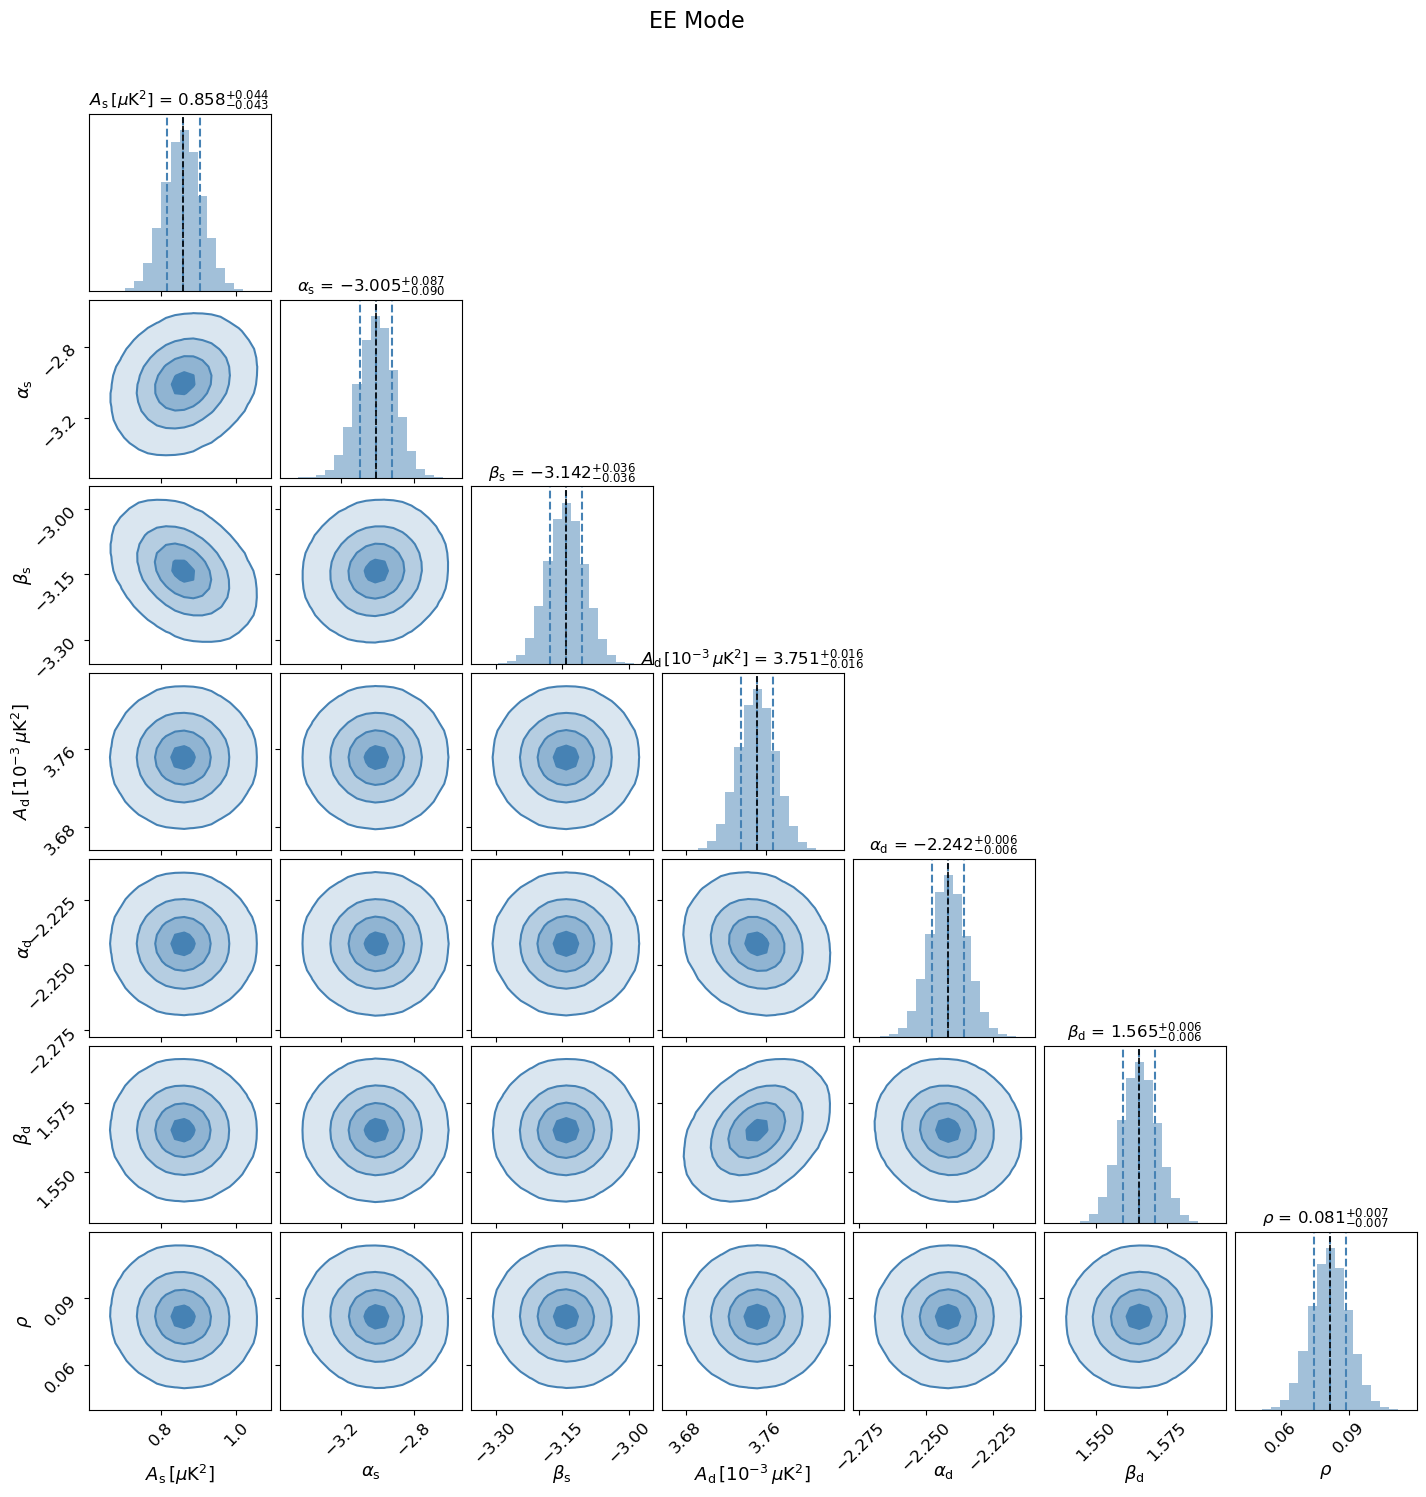

In [13]:
# Plot and save the corner plot
fig_EE = functions.plot_corner(samples_free_EE, param_map_EE, save_path_EE, title=f'EE Mode')

In [14]:
# Prepare BB data and run MCMC (power-law with prior and cross-only pairs)
fit_data_BB = functions.prepare_mcmc_data(
    spectra_dict,
    band_list=band_list,
    modes=['BB'],
    ell_min=ell_min,
    ell_max=ell_max,
    band_pairs=band_pairs
)

# Run MCMC with the selected fitting mode
sampler_BB, samples_full_BB, samples_free_BB, param_map_BB, chi2_reduced_BB = functions.run_mcmc(
    fit_data=fit_data_BB,
    fit_components=fit_components,
    fit_c_terms=fit_c_terms,
    nwalkers=nwalkers,
    ninter=ninter,
    discard_fraction=discard_fraction,
    verbose=True,  # Show progress bar
    fit_mode=fitting_mode,
    color_correction=True
)

[run_mcmc] Color corrections enabled (alpha-polynomials per band).
[run_mcmc] Available cores: 20
[run_mcmc] Using 20 cores for walker parallelization
[run_mcmc] Starting MCMC...


100%|██████████| 25000/25000 [39:39<00:00, 10.50it/s]


[run_mcmc] MCMC completed. 2500000 usable samples after burn-in.
[run_mcmc] Reduced chi-squared at best fit: 2.8684


[plot_corner] Saved corner plot to: /home/pablo/Desktop/master/tfm/figures/corner/corner_quijote_galcut10_sync_dust_cross_BB_full_bin_20-199.pdf


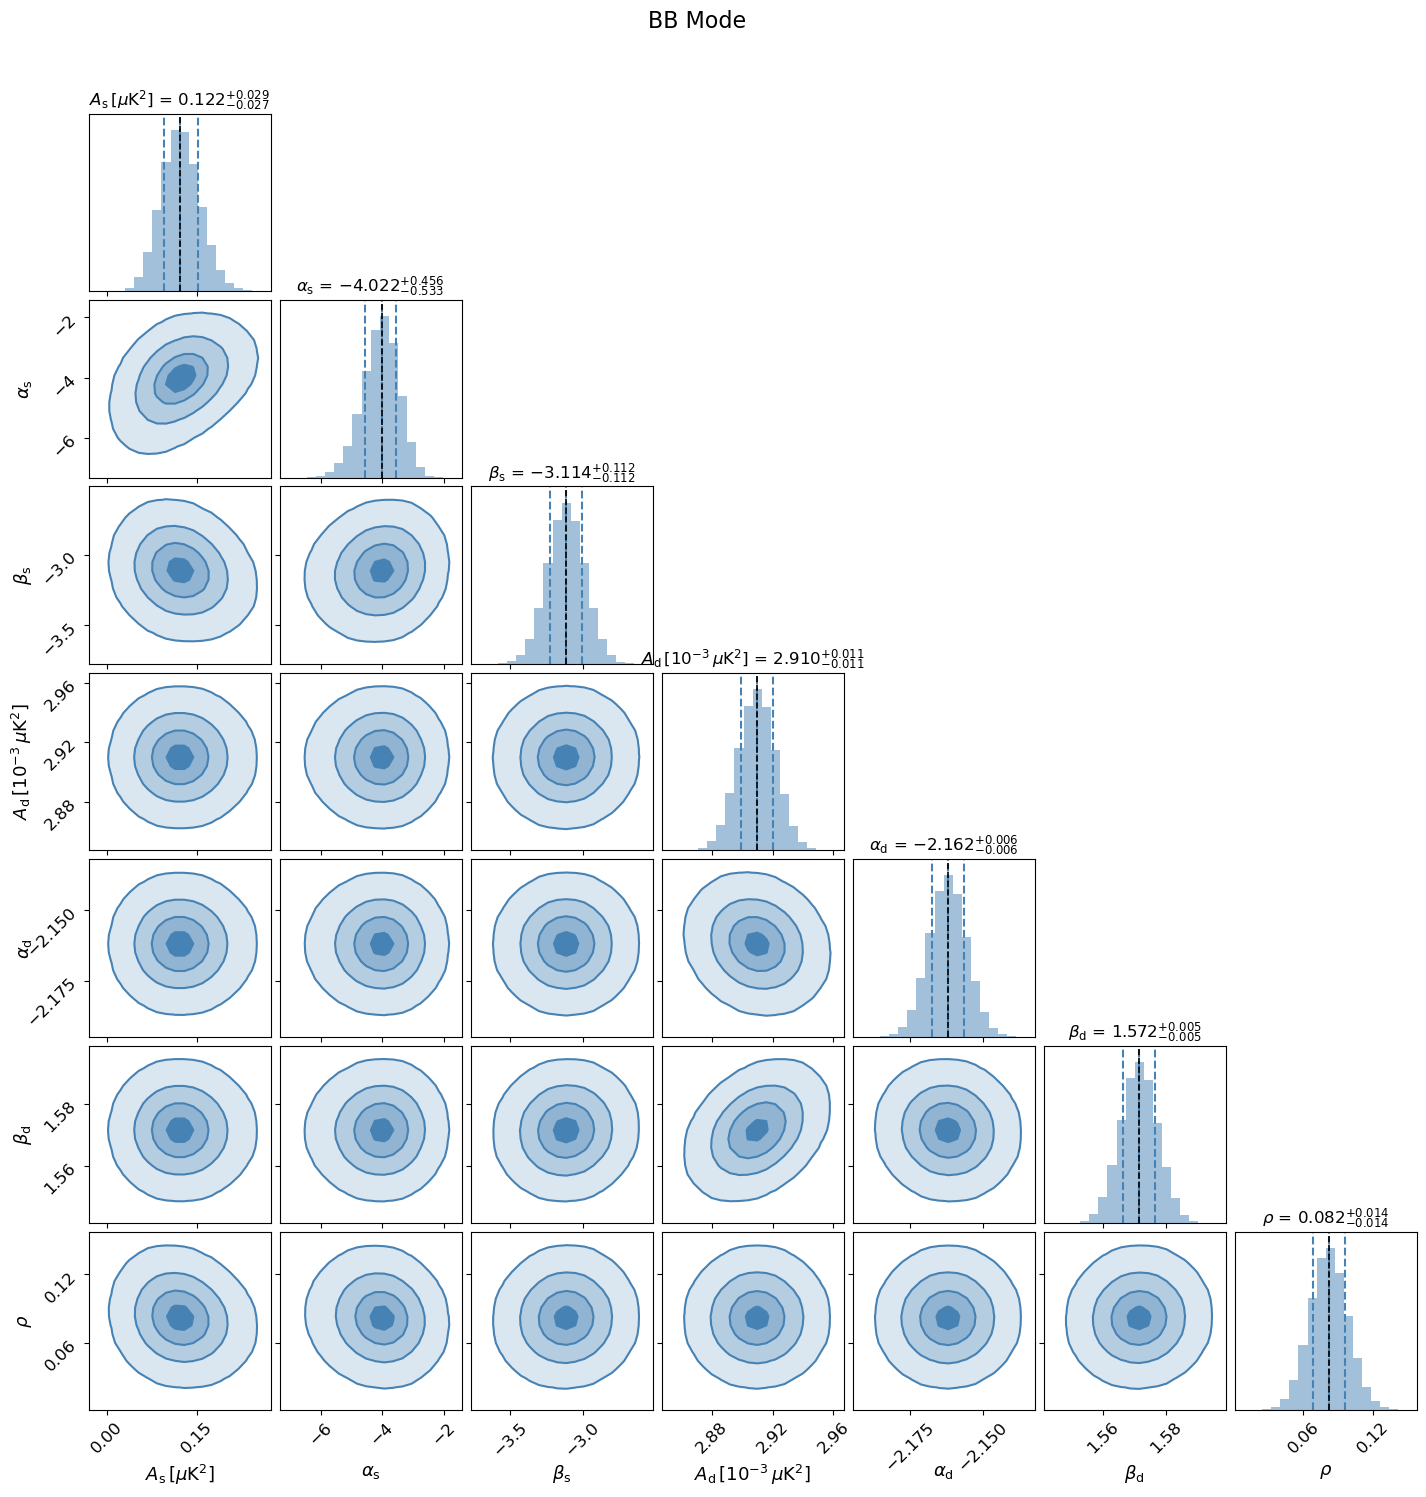

In [15]:
# Plot and save the corner plot
fig_BB = functions.plot_corner(samples_free_BB, param_map_BB, save_path_BB, title=f'BB Mode')

$\textbf{Joint EE-BB fitting}$

In [16]:
# Prepare EE-BB data and run MCMC
fit_data_EE_BB = functions.prepare_mcmc_data(
    spectra_dict,
    band_list=band_list,
    modes=['EE', 'BB'],
    ell_min=ell_min,
    ell_max=ell_max,
    band_pairs=band_pairs
)

# Run MCMC with the selected fitting mode
sampler_EE_BB, samples_full_EE_BB, samples_free_EE_BB, param_map_EE_BB, chi2_reduced_EE_BB = functions.run_mcmc(
    fit_data=fit_data_EE_BB,
    fit_components=fit_components,
    fit_c_terms=fit_c_terms,
    nwalkers=nwalkers,
    ninter=ninter,
    discard_fraction=discard_fraction,
    verbose=True,  # Show progress bar
    fit_mode=fitting_mode,
    color_correction=True,
    joint_analysis = True
)

[run_mcmc_joint] Color corrections enabled.
[run_mcmc_joint] Joint EE-BB analysis
[run_mcmc_joint] Parameters: ['A_s_EE', 'A_s_BB', 'alpha_s', 'beta_s', 'A_d_EE', 'A_d_BB', 'alpha_d', 'beta_d', 'rho']
[run_mcmc_joint] Total parameters: 9
[run_mcmc_joint] EE data points: 728
[run_mcmc_joint] BB data points: 728
[run_mcmc_joint] Using 20 processes with 200 walkers
[run_mcmc_joint] Running 25000 iterations...


100%|██████████| 25000/25000 [1:17:53<00:00,  5.35it/s]


[run_mcmc_joint] MCMC completed. 2500000 samples after burn-in.
[run_mcmc_joint] Reduced chi-squared at best fit: 3.2013


[plot_corner] Saved corner plot to: /home/pablo/Desktop/master/tfm/figures/corner/corner_quijote_galcut10_sync_dust_cross_EE-BB_full_bin_20-199.pdf


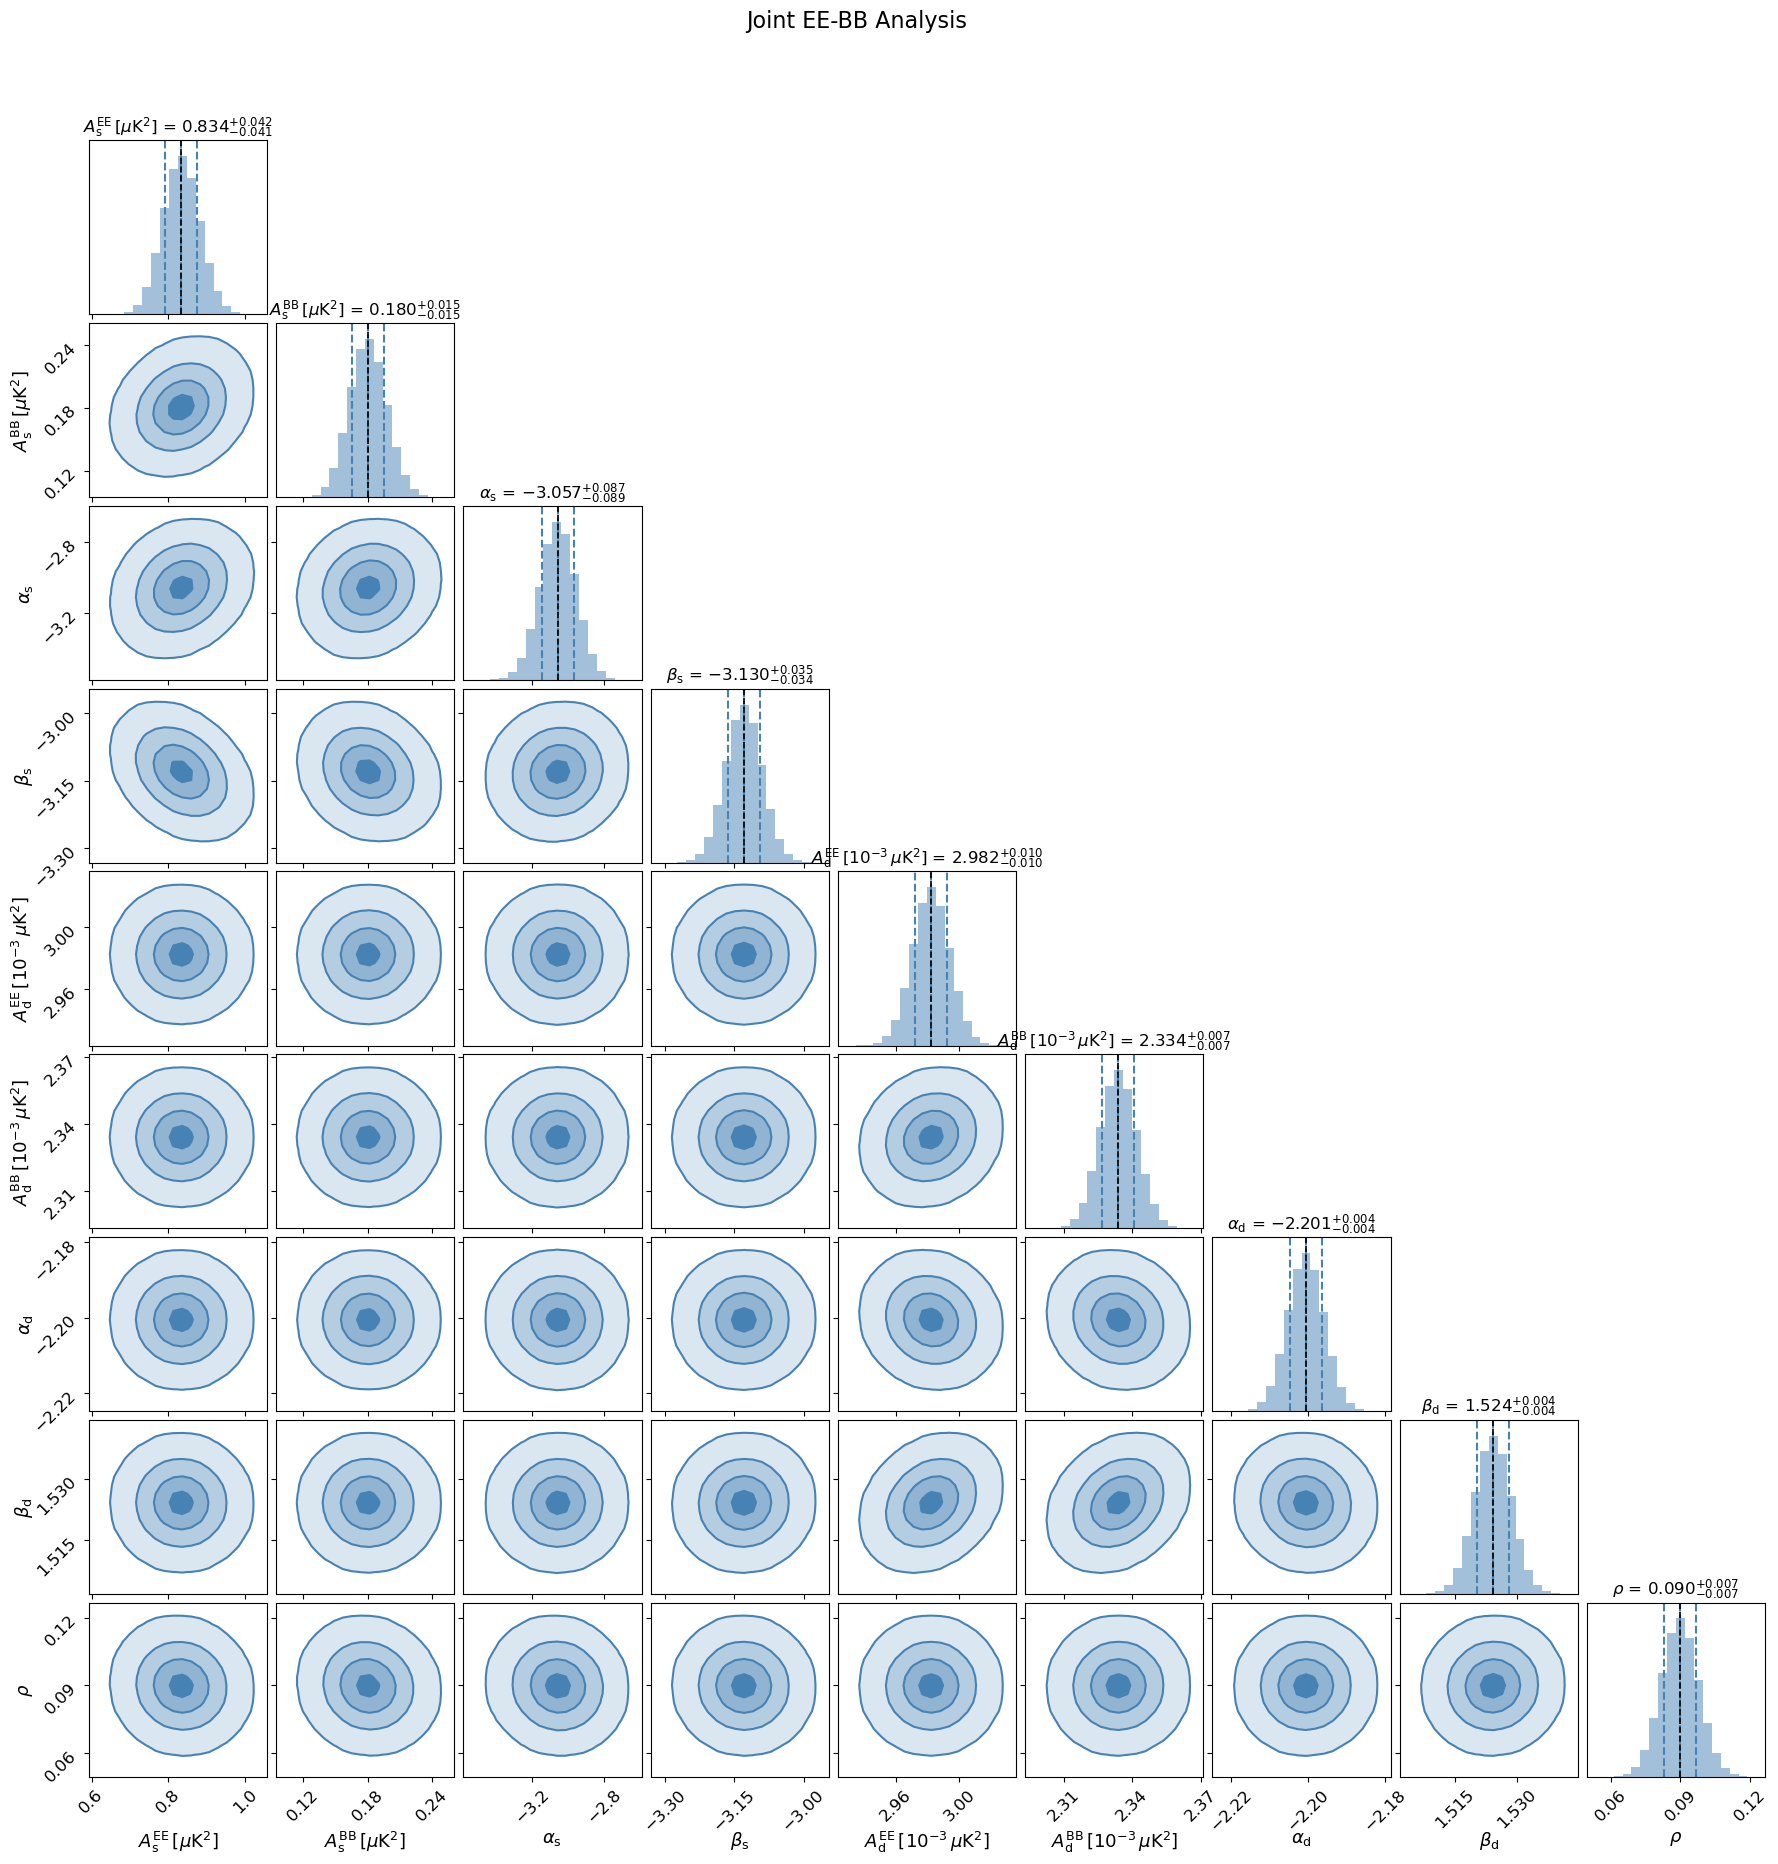

In [17]:
# Plot and save the corner plot
fig_joint = functions.plot_corner(
    samples_free_EE_BB, param_map_EE_BB,save_path_EE_BB, title='Joint EE-BB Analysis'
)

$\textbf{Part 9: Bin to bin fitting}$

In [3]:
# Configuration for bin-to-bin fitting (Gaussian priors + cross-only pairs)
from functions import set_gaussian_priors

# Apply the same Gaussian priors:
# - beta_s ~ N(-3.1, 0.18)
# - beta_d ~ N(1.55, 0.05)
# - alpha_s ~ N(-3.0, 0.30)
# - alpha_d ~ N(-2.48, 0.20)  (average of Planck alpha_EE ~ -2.42 and alpha_BB ~ -2.54)
#   T_d fixed at 19.6 K inside the dust scaling (implicit delta prior)
set_gaussian_priors({
    'beta_s': (-3.1, 0.30),
    # 'beta_d': (1.55, 0.05),
    # 'alpha_s': (-3.0, 0.30),
    # 'alpha_d': (-2.48, 0.20),
})

fit_mode_btb = 'bin-to-bin'  # Use 'bin-to-bin' mode

# Multipole range
ell_min_btb = 20
ell_max_btb = 200

# Sampler configuration
nwalkers_btb = 100
ninter_btb = 15000
discard_fraction_btb = 0.5

# Fit synchrotron, dust, and cross components per bin
fit_components_btb = ('sync', 'dust', 'cross')

# # Build cross-only band pairs across all bands (exclude autos)
# band_pairs_cross_all = []
# for i in range(len(band_list)):
#     for j in range(i + 1, len(band_list)):
#         band_pairs_cross_all.append(f"{band_list[i]}_{band_list[j]}")

# band_pairs_btb = band_pairs_cross_all

band_pairs_btb = 'all'

# Load corrected spectra
spectra_dict_btb = functions.read_corrected_cls(path_corrected_spectra, band_list)

In [ ]:
# Prepare EE data and run bin-to-bin MCMC (cross-only pairs)
fit_data_EE = functions.prepare_mcmc_data(
    spectra_dict_btb,
    band_list=band_list,
    modes=['EE'],
    ell_min=ell_min_btb,
    ell_max=ell_max_btb,
    band_pairs=band_pairs_btb
)

# Run bin-to-bin MCMC for EE mode
samplers_EE, samples_full_EE, samples_free_EE, param_names_btb, chi2_reduced_EE = functions.run_mcmc(
    fit_data=fit_data_EE,
    fit_components=fit_components_btb,
    fit_c_terms=False,
    nwalkers=nwalkers_btb,
    ninter=ninter_btb,
    discard_fraction=discard_fraction_btb,
    verbose=True,
    fit_mode=fit_mode_btb,
    color_correction=True
)

[run_mcmc bin-to-bin] Fitting 9 ell bins independently
[run_mcmc bin-to-bin] Parameters per bin: ['A_s', 'beta_s', 'A_d', 'beta_d', 'rho']
[run_mcmc bin-to-bin] Available cores: 20
[run_mcmc bin-to-bin] Using 20 cores for walker parallelization
[run_mcmc bin-to-bin] Color corrections enabled (alpha=2+beta per band).

[run_mcmc bin-to-bin] Processing bin 1/9 (ell=29.0)


  2%|▏         | 228/15000 [00:16<17:36, 13.98it/s]Process ForkPoolWorker-10:


emcee: Exception while calling your likelihood function:

Process ForkPoolWorker-2:
Process ForkPoolWorker-14:
Process ForkPoolWorker-15:
Process ForkPoolWorker-13:


emcee: Exception while calling your likelihood function:

...

  File "/home/pablo/anaconda3/envs/cmb_py/lib/python3.11/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
           ^^^^^^^^^^^^^^^^^^^^^^^^^



   kwargs: 


KeyboardInterrupt


  kwargs:{}   exception:{} {}


{}
  exception:  exception:  exception:



  exception:


Traceback (most recent call last):
  File "/home/pablo/anaconda3/envs/cmb_py/lib/python3.11/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/pablo/Desktop/master/tfm/python/1-methodology_tests/functions.py", line 4760, in _lnprob_bin_to_bin
    ll = _lnlike_bin_to_bin(theta, datasets, ell, y_all, yerr_all, fit_components, param_names, cc_dict)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/pablo/Desktop/master/tfm/python/1-methodology_tests/functions.py", line 4879, in _lnlike_bin_to_bin
    model_val += rho * np.sqrt(A_s * A_d) * ((s1/cc_s1) * (d2/cc_d2) + (s2/cc_s2) * (d1/cc_d1))
                       ^^^^^^^^^^^^^^^^^^
  File "/home/pablo/anaconda3/envs/cmb_p

In [13]:
# Prepare BB data and run bin-to-bin MCMC (cross-only pairs)
fit_data_BB = functions.prepare_mcmc_data(
    spectra_dict_btb,
    band_list=band_list,
    modes=['BB'],
    ell_min=ell_min_btb,
    ell_max=ell_max_btb,
    band_pairs=band_pairs_btb
)

# Run bin-to-bin MCMC for BB mode
samplers_BB, samples_full_BB, samples_free_BB, param_names_btb, chi2_reduced_BB = functions.run_mcmc(
    fit_data=fit_data_BB,
    fit_components=fit_components_btb,
    fit_c_terms=False,
    nwalkers=nwalkers_btb,
    ninter=ninter_btb,
    discard_fraction=discard_fraction_btb,
    verbose=True,
    fit_mode=fit_mode_btb,
    color_correction=True
)

[run_mcmc bin-to-bin] Fitting 9 ell bins independently
[run_mcmc bin-to-bin] Parameters per bin: ['A_s', 'beta_s', 'A_d', 'beta_d', 'rho']
[run_mcmc bin-to-bin] Available cores: 20
[run_mcmc bin-to-bin] Using 20 cores for walker parallelization
[run_mcmc bin-to-bin] Color corrections enabled (alpha=2+beta per band).

[run_mcmc bin-to-bin] Processing bin 1/9 (ell=29.0)


100%|██████████| 15000/15000 [25:53<00:00,  9.66it/s]

[run_mcmc bin-to-bin] Bin 1 completed. χ²_red = 1.2428

[run_mcmc bin-to-bin] Processing bin 2/9 (ell=49.0)



100%|██████████| 15000/15000 [25:46<00:00,  9.70it/s]

[run_mcmc bin-to-bin] Bin 2 completed. χ²_red = 1.4590

[run_mcmc bin-to-bin] Processing bin 3/9 (ell=69.0)


...

[run_mcmc bin-to-bin] Bin 7 completed. χ²_red = 1.1875

[run_mcmc bin-to-bin] Processing bin 8/9 (ell=169.0)



100%|██████████| 15000/15000 [35:44<00:00,  6.99it/s]


[run_mcmc bin-to-bin] Bin 8 completed. χ²_red = 1.5553

[run_mcmc bin-to-bin] Processing bin 9/9 (ell=189.0)


100%|██████████| 15000/15000 [35:19<00:00,  7.08it/s]


[run_mcmc bin-to-bin] Bin 9 completed. χ²_red = 1.7179

[run_mcmc bin-to-bin] All 9 bins completed successfully
[run_mcmc bin-to-bin] Mean χ²_red = 1.4340 ± 0.1950


In [14]:
table_save_path_latex = f'/home/pablo/Desktop/master/tfm/tables/bin_to_bin_results_{mask_name}{name_suffix}.tex'

# Generate LaTeX table
table_latex = functions.create_bin_to_bin_table(
    fit_data_EE=fit_data_EE,
    fit_data_BB=fit_data_BB,
    samples_free_list_EE=samples_free_EE,
    samples_free_list_BB=samples_free_BB,
    param_names=param_names_btb,
    ell1=ell_1,
    ell2=ell_2,
    save_path=table_save_path_latex,
    format='latex'
)

# Generate ASCII table for quick viewing
table_ascii = functions.create_bin_to_bin_table(
    fit_data_EE=fit_data_EE,
    fit_data_BB=fit_data_BB,
    samples_free_list_EE=samples_free_EE,
    samples_free_list_BB=samples_free_BB,
    param_names=param_names_btb,
    ell1=ell_1,
    ell2=ell_2,
    save_path=None,
    format='ascii'
)

print(table_ascii)

[create_bin_to_bin_table] Table saved to: /home/pablo/Desktop/master/tfm/tables/bin_to_bin_results_quijote_galcut10_full_bin_20-199.tex
Bin-to-bin fit results
EE mode (top) and BB mode (bottom)
For BB mode, amplitudes A_s and A_d are shown in the same units as EE
 ell range   | ell_eff  |        A_s_EE        |      beta_s_EE       |        A_d_EE        |      beta_d_EE       |        rho_EE        |
------------------------------------------------------------------------------------------------------------------------------------------------------
   20--39    |   29.0   |     26.14 ± 0.69      |     -3.08 ± 0.02      |     48.95 ± 0.27      |      1.48 ± 0.01      |     0.086 ± 0.007     |
   40--59    |   49.0   |      3.65 ± 0.23      |     -3.12 ± 0.05      |      7.87 ± 0.07      |      1.51 ± 0.01      |     0.125 ± 0.013     |
   60--79    |   69.0   |      1.48 ± 0.12      |     -3.23 ± 0.07      |      4.78 ± 0.04      |      1.53 ± 0.01      |     0.041 ± 0.015     |
   80-

[plot_bin_to_bin_results] Figure saved to: /home/pablo/Desktop/master/tfm/figures/bin-to-bin/bin_to_bin_evolution_quijote_galcut10_full_bin_20-199.pdf


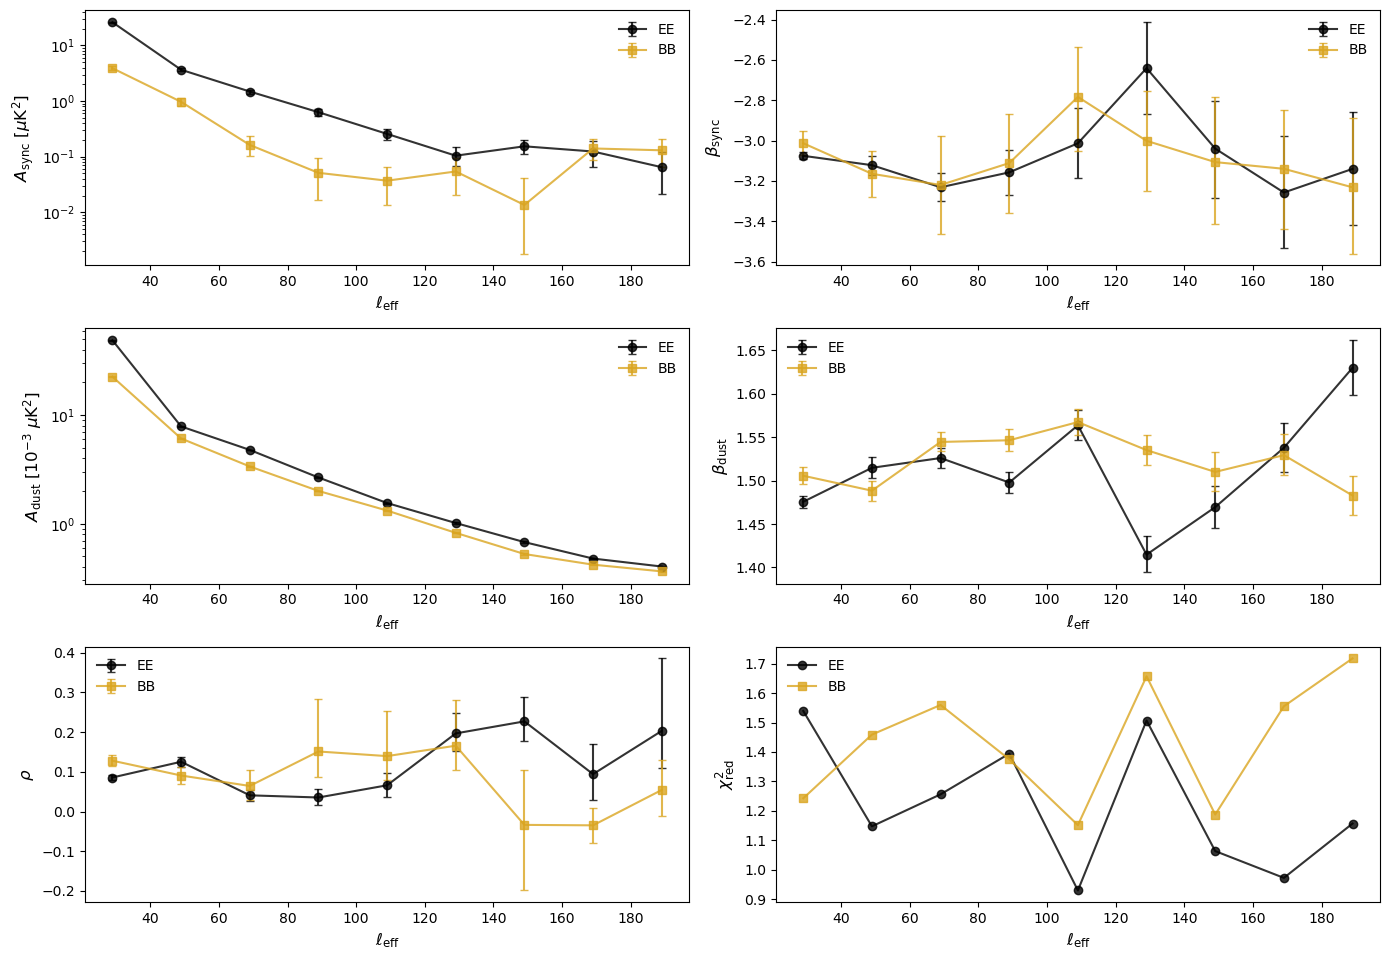

In [15]:
# Plot parameter evolution with ell
plot_save_path = f'/home/pablo/Desktop/master/tfm/figures/bin-to-bin/bin_to_bin_evolution_{mask_name}{name_suffix}.pdf'

fig = functions.plot_bin_to_bin_results(
    fit_data_EE=fit_data_EE,
    fit_data_BB=fit_data_BB,
    samples_free_list_EE=samples_free_EE,
    samples_free_list_BB=samples_free_BB,
    param_names=param_names_btb,
    chi2_reduced_EE=chi2_reduced_EE,
    chi2_reduced_BB=chi2_reduced_BB,
    save_path=plot_save_path,
    figsize=(14, 10)
)

$\textbf{Convergence check for bin-to-bin}$

[plot_bin_to_bin_convergence] Figure saved to: /home/pablo/Desktop/master/tfm/figures/bin-to-bin/bin_to_bin_convergence_quijote_galcut10_full_bin_20-199.pdf


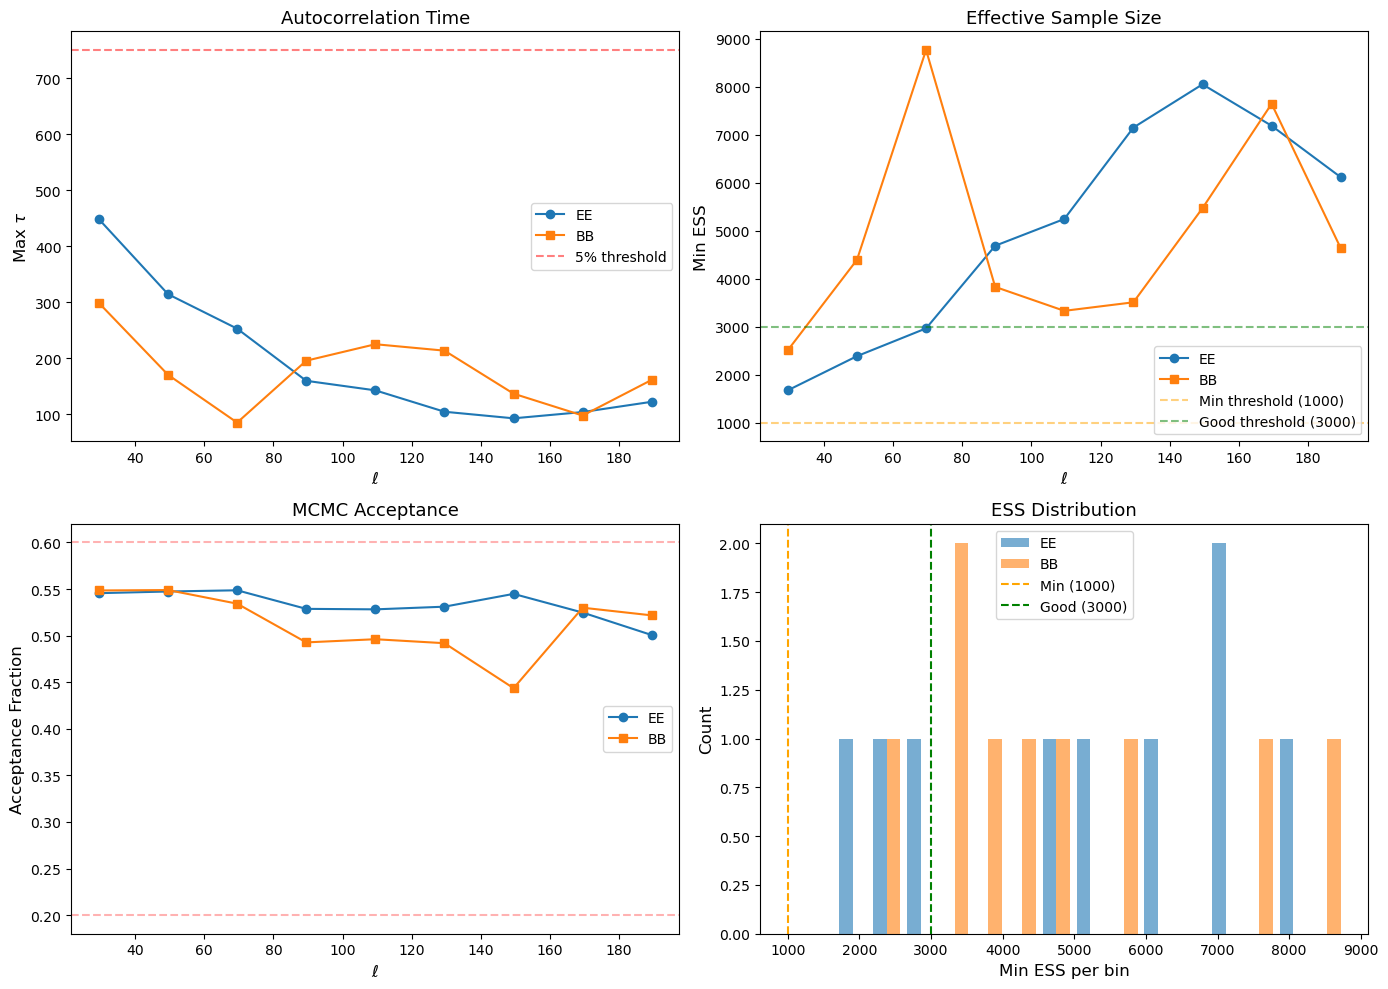

In [16]:
convergence_save_path = f'/home/pablo/Desktop/master/tfm/figures/bin-to-bin/bin_to_bin_convergence_{mask_name}{name_suffix}.pdf'

fig_convergence = functions.plot_bin_to_bin_convergence(
    samplers_EE=samplers_EE,
    samplers_BB=samplers_BB,
    ell_1=ell_1,
    ell_2=ell_2,
    ninter=ninter_btb,
    discard_fraction=discard_fraction_btb,
    save_path=convergence_save_path,
    figsize=(14, 10)
)

In [71]:
path_theoretical_spectra = os.path.join(out_path, f'corrected_theoretical_power_spectra_{mask_name}.fits')

spectra_dict = functions.read_corrected_cls(path_corrected_spectra, band_list)
# theoretical_spectra_dict = functions.read_spectra_from_fits(path_theoretical_spectra, band_list)

ell = spectra_dict['11_11']['ell_eff'][3:20]
cl_11_11   = spectra_dict['11_11']['EE']['SPECTRUM'][3:20]
cl_353_353 = spectra_dict['353_353']['EE']['SPECTRUM'][3:20]
cl_11_353  = spectra_dict['11_353']['EE']['SPECTRUM'][3:20]

# cl_11_11_theo   = theoretical_spectra_dict['11_11']['EE'][3:20]
# cl_353_353_theo = theoretical_spectra_dict['353_353']['EE'][3:20]
# cl_11_353_theo  = theoretical_spectra_dict['11_353']['EE'][3:20]


rho = cl_11_353 / np.sqrt(cl_11_11 * cl_353_353)
# rho_theo = cl_11_353_theo / np.sqrt(cl_11_11_theo * cl_353_353_theo)
print(rho)
# print(cl_11_11)
# print(cl_353_353)
# print(cl_11_353)
# print(rho_theo)

[ 0.02685915 -0.06121989 -0.03707708 -0.04774536 -0.06585212  0.02395937
  0.129362   -0.00752252]
